<a href="https://colab.research.google.com/github/ndavidd-github/ndavidd/blob/master/Final_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **The Scenario**

In this activity, It seems that I work for a company that facilitates scooter-sharing. Using these systems, users can rent a scooter in one place and return it to another.Currently, there are hundreds of scooter programs around the world. I will be using data about scooter rentals over a two-year period.

My goal will be to understand and predict daily scooter rentals using linear regression.

# **Import Python Libraries**
Python libraries help to extend the Python programming language -- or to help make our tasks easier. There are lots of Python libraries and they do lots of different things. For our purposes, we will import "**pandas**" to load and manipulate data, "**seaborn**" for visualization, and "**scipy**" for statistics.

In [1]:
# import the appropriate python libraries.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.io as pio
pio.templates.default = "plotly_white"
import warnings
warnings.filterwarnings("ignore")
from scipy import stats
from scipy.stats import norm, skew

# **Load Data (Option #1).**

One of the biggest challenges that people run into with Google Colab is loading data. For simplicity, our dataset from this example has already been stored in the cloud on Github. (We also used a URL shortener to make it easier to type.) To see what this file looks like, you can copy the following link (http://bit.ly/scooter-rentals) and paste into your browser window. Another option for loading your data is from your own hard drive.

In [2]:
# Load the CSV file into a dataframe.
df_scooter = pd.read_csv('http://bit.ly/scooter-rentals')


# **Generate Desciptive Stats**

Before we go farther, we should explore our dataset to better understand it.  This will include previewing the columns and their datatypes, generating descriptive statistics, and basic graphing.

In [3]:
#List all columns and their data types. (What is the datatype listed for the "registered" column?)

df_scooter.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            731 non-null    int64  
 1   date          731 non-null    object 
 2   yr            731 non-null    int64  
 3   mnth          731 non-null    int64  
 4   weekday       731 non-null    int64  
 5   workday       731 non-null    int64  
 6   season        731 non-null    int64  
 7   holiday       731 non-null    int64  
 8   temp          731 non-null    float64
 9   atemp         731 non-null    float64
 10  hum           731 non-null    float64
 11  wind          731 non-null    float64
 12  unregistered  731 non-null    int64  
 13  registered    731 non-null    int64  
dtypes: float64(4), int64(9), object(1)
memory usage: 80.1+ KB


In [13]:
#preview all records of Data
# Shows the entire DataFrame
print(df_scooter.to_string())
df_scooter.head()


      ID        date  yr  mnth  weekday  workday  season  holiday      temp     atemp       hum      wind  unregistered  registered
0      1    1/1/2011   0     1        6        0       1        0  0.344167  0.363625  0.805833  0.160446           331         654
1      2    1/2/2011   0     1        0        0       1        0  0.363478  0.353739  0.696087  0.248539           131         670
2      3    1/3/2011   0     1        1        1       1        0  0.196364  0.189405  0.437273  0.248309           120        1229
3      4    1/4/2011   0     1        2        1       1        0  0.200000  0.212122  0.590435  0.160296           108        1454
4      5    1/5/2011   0     1        3        1       1        0  0.226957  0.229270  0.436957  0.186900            82        1518
5      6    1/6/2011   0     1        4        1       1        0  0.204348  0.233209  0.518261  0.089565            88        1518
6      7    1/7/2011   0     1        5        1       1        0  0.196522 

,ID,date,yr,mnth,weekday,workday,season,holiday,temp,atemp,hum,wind,unregistered,registered
0,1,1/1/2011,0,1,6,0,1,0,0.344167,0.363625,0.805833,0.160446,331,654
1,2,1/2/2011,0,1,0,0,1,0,0.363478,0.353739,0.696087,0.248539,131,670
2,3,1/3/2011,0,1,1,1,1,0,0.196364,0.189405,0.437273,0.248309,120,1229
3,4,1/4/2011,0,1,2,1,1,0,0.200000,0.212122,0.590435,0.160296,108,1454
4,5,1/5/2011,0,1,3,1,1,0,0.226957,0.229270,0.436957,0.186900,82,1518


In [9]:
# Generate descriptive stats.
df_scooter.describe()

,ID,yr,mnth,weekday,workday,season,holiday,temp,atemp,hum,wind,unregistered,registered
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,0.500684,6.519836,2.997264,0.683995,2.496580,0.028728,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367
std,211.165812,0.500342,3.451913,2.004787,0.465233,1.110807,0.167155,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377
min,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000
25%,183.500000,0.000000,4.000000,1.000000,0.000000,2.000000,0.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000
50%,366.000000,1.000000,7.000000,3.000000,1.000000,3.000000,0.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000
75%,548.500000,1.000000,10.000000,5.000000,1.000000,3.000000,0.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000
max,731.000000,1.000000,12.000000,6.000000,1.000000,4.000000,1.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000


# **Calculate the dimensions of the dataset**.

#### How many records (or rows) are in the data?

In [11]:
#calculate the demension of Dataset#
df_scooter.shape

(731, 14)

**Change Field Names**

I am change the following field names to make them easier to understand and after I will display all the columns to confirm the changes above were completed successfully

In [14]:
# Rename fields
df = df_scooter.rename(columns={
    "yr": "year",
    "mnth": "month",
    "hum": "humidity_norm",
    "temp": "temp_norm",
    "atemp": "temp_felt_norm",
    "wind": "wind_norm",
    "registered": "rentals_registered",
    "unregistered": "rentals_unregistered"
})

print(df.head())


   ID      date  year  month  weekday  workday  season  holiday  temp_norm  \
0   1  1/1/2011     0      1        6        0       1        0   0.344167   
1   2  1/2/2011     0      1        0        0       1        0   0.363478   
2   3  1/3/2011     0      1        1        1       1        0   0.196364   
3   4  1/4/2011     0      1        2        1       1        0   0.200000   
4   5  1/5/2011     0      1        3        1       1        0   0.226957   

   temp_felt_norm  humidity_norm  wind_norm  rentals_unregistered  \
0        0.363625       0.805833   0.160446                   331   
1        0.353739       0.696087   0.248539                   131   
2        0.189405       0.437273   0.248309                   120   
3        0.212122       0.590435   0.160296                   108   
4        0.229270       0.436957   0.186900                    82   

   rentals_registered  
0                 654  
1                 670  
2                1229  
3                145

# I am previewing the first 5 records

In [16]:
#Preview the first 5 records in the dataset.For the last row in the output, what
#is the value for "rentals_unregistered"?

# Preview the first 5 records
print(df.head())

# Get the value of "rentals_unregistered" in the last row of that preview
value = df.head().iloc[-1]["rentals_unregistered"]
print("Value for rentals_unregistered in last row:", value)


   ID      date  year  month  weekday  workday  season  holiday  temp_norm  \
0   1  1/1/2011     0      1        6        0       1        0   0.344167   
1   2  1/2/2011     0      1        0        0       1        0   0.363478   
2   3  1/3/2011     0      1        1        1       1        0   0.196364   
3   4  1/4/2011     0      1        2        1       1        0   0.200000   
4   5  1/5/2011     0      1        3        1       1        0   0.226957   

   temp_felt_norm  humidity_norm  wind_norm  rentals_unregistered  \
0        0.363625       0.805833   0.160446                   331   
1        0.353739       0.696087   0.248539                   131   
2        0.189405       0.437273   0.248309                   120   
3        0.212122       0.590435   0.160296                   108   
4        0.229270       0.436957   0.186900                    82   

   rentals_registered  
0                 654  
1                 670  
2                1229  
3                145

# Replace Data

In the “season” field, replace the numbers (1, 2, 3, 4) with the following season names:

1 = “winter”
2 = “spring”
3 = “summer”
4 = “fall”

In [17]:
# Replace season numbers with names
season_map = {
    1: "winter",
    2: "spring",
    3: "summer",
    4: "fall"
}

df["season"] = df["season"].map(season_map)

print(df)


      ID        date  year  month  weekday  workday  season  holiday  \
0      1    1/1/2011     0      1        6        0  winter        0   
1      2    1/2/2011     0      1        0        0  winter        0   
2      3    1/3/2011     0      1        1        1  winter        0   
3      4    1/4/2011     0      1        2        1  winter        0   
4      5    1/5/2011     0      1        3        1  winter        0   
..   ...         ...   ...    ...      ...      ...     ...      ...   
726  727  12/27/2012     1     12        4        1  winter        0   
727  728  12/28/2012     1     12        5        1  winter        0   
728  729  12/29/2012     1     12        6        0  winter        0   
729  730  12/30/2012     1     12        0        0  winter        0   
730  731  12/31/2012     1     12        1        1  winter        0   

     temp_norm  temp_felt_norm  humidity_norm  wind_norm  \
0     0.344167        0.363625       0.805833   0.160446   
1     0.363478 

** Season numbers Replaced with names**

In [18]:
# Shows the entire DataFrame updated
print(df.to_string())
df_scooter.head()

      ID        date  year  month  weekday  workday  season  holiday  temp_norm  temp_felt_norm  humidity_norm  wind_norm  rentals_unregistered  rentals_registered
0      1    1/1/2011     0      1        6        0  winter        0   0.344167        0.363625       0.805833   0.160446                   331                 654
1      2    1/2/2011     0      1        0        0  winter        0   0.363478        0.353739       0.696087   0.248539                   131                 670
2      3    1/3/2011     0      1        1        1  winter        0   0.196364        0.189405       0.437273   0.248309                   120                1229
3      4    1/4/2011     0      1        2        1  winter        0   0.200000        0.212122       0.590435   0.160296                   108                1454
4      5    1/5/2011     0      1        3        1  winter        0   0.226957        0.229270       0.436957   0.186900                    82                1518
5      6    1/6/

,ID,date,yr,mnth,weekday,workday,season,holiday,temp,atemp,hum,wind,unregistered,registered
0,1,1/1/2011,0,1,6,0,1,0,0.344167,0.363625,0.805833,0.160446,331,654
1,2,1/2/2011,0,1,0,0,1,0,0.363478,0.353739,0.696087,0.248539,131,670
2,3,1/3/2011,0,1,1,1,1,0,0.196364,0.189405,0.437273,0.248309,120,1229
3,4,1/4/2011,0,1,2,1,1,0,0.200000,0.212122,0.590435,0.160296,108,1454
4,5,1/5/2011,0,1,3,1,1,0,0.226957,0.229270,0.436957,0.186900,82,1518


# Create a New Column

Create a new column called "rentals_total" that sums registered and unregistered rentals.  Confirm that it was calculated correctly by previewing a few records.

In [26]:
# Create new column for total rentals
df["rentals_total"] = df["rentals_registered"] + df["rentals_unregistered"]

# Preview first few records to confirm
print(df.head())

   ID      date  year  month  weekday  workday  season  holiday  temp_norm  \
0   1  1/1/2011     0      1        6        0  winter        0   0.344167   
1   2  1/2/2011     0      1        0        0  winter        0   0.363478   
2   3  1/3/2011     0      1        1        1  winter        0   0.196364   
3   4  1/4/2011     0      1        2        1  winter        0   0.200000   
4   5  1/5/2011     0      1        3        1  winter        0   0.226957   

   temp_felt_norm  humidity_norm  wind_norm  rentals_unregistered  \
0        0.363625       0.805833   0.160446                   331   
1        0.353739       0.696087   0.248539                   131   
2        0.189405       0.437273   0.248309                   120   
3        0.212122       0.590435   0.160296                   108   
4        0.229270       0.436957   0.186900                    82   

   rentals_registered  rentals_total  
0                 654            985  
1                 670            801  

In [27]:
# What were the total rentals on 1/5/2011?

# Filtered for the mentioned date using the correct 'df' and 'date' column
rentals_on_date = df[df['date'] == '1/5/2011']['rentals_total'].values[0]
print(f"Total rentals on 1/5/2011: {rentals_on_date}")

Total rentals on 1/5/2011: 1600


# Generate Descriptive Stats

Generate descriptive stats for the numeric columns in the dataset.

What is the standard deviation for "rentals_total"?

In [24]:

# Generate descriptive statistics for numeric columns
stats = df.describe()

print(stats)

               ID        year       month     weekday     workday     holiday  \
count  731.000000  731.000000  731.000000  731.000000  731.000000  731.000000   
mean   366.000000    0.500684    6.519836    2.997264    0.683995    0.028728   
std    211.165812    0.500342    3.451913    2.004787    0.465233    0.167155   
min      1.000000    0.000000    1.000000    0.000000    0.000000    0.000000   
25%    183.500000    0.000000    4.000000    1.000000    0.000000    0.000000   
50%    366.000000    1.000000    7.000000    3.000000    1.000000    0.000000   
75%    548.500000    1.000000   10.000000    5.000000    1.000000    0.000000   
max    731.000000    1.000000   12.000000    6.000000    1.000000    1.000000   

        temp_norm  temp_felt_norm  humidity_norm   wind_norm  \
count  731.000000      731.000000     731.000000  731.000000   
mean     0.495385        0.474354       0.627894    0.190486   
std      0.183051        0.162961       0.142429    0.077498   
min      0.059

**Create a Pivot Table (#1)**

Create a pivot table (using Pandas) that has "year" and "season" as indices (in that order) and that calculates the sum, minimum, and maximum for the "rentals_total" columns.

In [29]:
# Create pivot table
pivot_table = pd.pivot_table(
    df,
    index=['year', 'season'],         # multi-level index
    values='rentals_total',           # column to aggregate
    aggfunc=['sum', 'min', 'max']     # aggregation functions
)

# Preview the pivot table
print(pivot_table.head())

                      sum           min           max
            rentals_total rentals_total rentals_total
year season                                          
0    fall          326137           627          5511
     spring        347316           795          5805
     summer        419650          1115          6043
     winter        150000           431          3239
1    fall          515476            22          8555


**Create a Pivot Table (#1)**

Create a pivot table (using Pandas) that has "year" and "season" as indices (in that order) and that calculates the sum, minimum, and maximum for the "rentals_total" columns.

**What was the maximum number of daily rentals where "year" = 1 and "season" = 3?**

In [31]:
# Filter dataset for year = 1 and season = 'summer'
filtered = df[(df['year'] == 1) & (df['season'] == 'summer')]

# Find maximum daily rentals
max_rentals = filtered['rentals_total'].max()

print(f"Maximum daily rentals where year=1 and season='summer': {max_rentals}")

Maximum daily rentals where year=1 and season='summer': 8714


**Create a Pivot Table (#2)**

Create a pivot table that has "year" and "month" as indices (in that order) and that sums and averages the "rentals_total".

***What was the total number of rentals (sum) where "year" = 0 and "month" = 8?***

In [33]:
# Create pivot table with year and month as indices
pivot_table2 = pd.pivot_table(
    df,
    index=['year', 'month'],          # multi-level index
    values='rentals_total',           # column to aggregate
    aggfunc=['sum', 'mean']           # aggregation functions
)

# Preview the pivot table
print(pivot_table2.head())

                     sum          mean
           rentals_total rentals_total
year month                            
0    1             38189   1231.903226
     2             48215   1721.964286
     3             64045   2065.967742
     4             94870   3162.333333
     5            135821   4381.322581


In [35]:
# What was the total number of rentals (sum) where "year" = 0 and "month" = 8?

# Filter dataset for year = 0 and month = 8
filtered = df[(df['year'] == 0) & (df['month'] == 8)]

# Calculate total rentals (sum)
total_rentals = filtered['rentals_total'].sum()

print(f"Total rentals where year=0 and month=8: {total_rentals}")

Total rentals where year=0 and month=8: 136691


# Generate Visualizations  

Generate a histogram to visualize the distribution of **"rentals_total" column**.  **Use seaborn's "displot".**

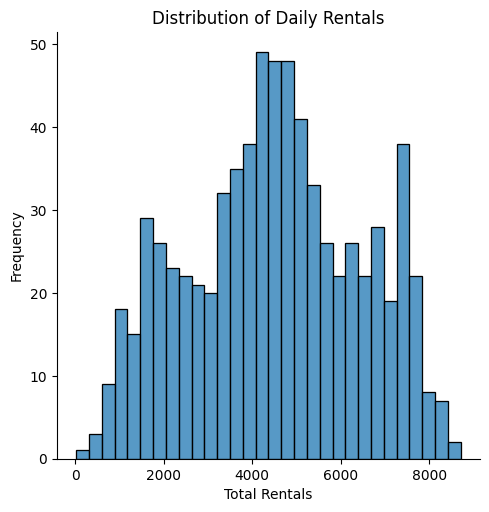

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram of rentals_total
sns.displot(df['rentals_total'], bins=30, kde=False)

# Add labels and title
plt.xlabel("Total Rentals")
plt.ylabel("Frequency")
plt.title("Distribution of Daily Rentals")
plt.show()

In [40]:
display(df.describe())

,ID,year,month,weekday,workday,holiday,temp_norm,temp_felt_norm,humidity_norm,wind_norm,rentals_unregistered,rentals_registered,rentals_total
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,0.500684,6.519836,2.997264,0.683995,0.028728,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,0.500342,3.451913,2.004787,0.465233,0.167155,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,0.000000,4.000000,1.000000,0.000000,0.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,1.000000,7.000000,3.000000,1.000000,0.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,1.000000,10.000000,5.000000,1.000000,0.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,1.000000,12.000000,6.000000,1.000000,1.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Generate **a scatterplo**t that has "**rentals_unregistered**" on **the x-axis** and "**rentals_registered**" on **the y-axis**.  Then, color the datapoints based on whether or not it was a workday.  This will help us understand the types of scotter rentals on weekdays versus weekends. Use seaborn's "scatterplot" function.  (As a note, when “workday” is 0, it is a weekend – Saturday or Sunday.)

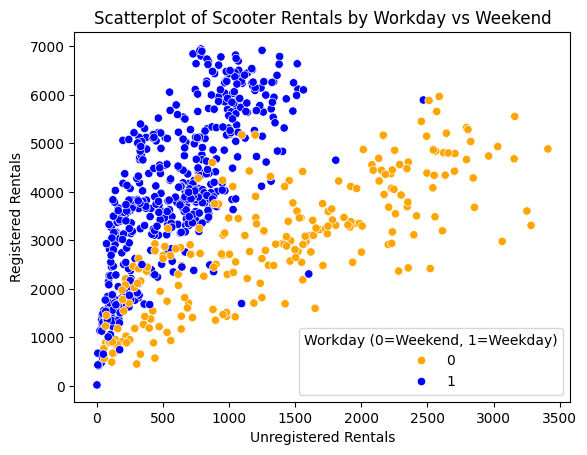

In [41]:
# a scatterplot that has "rentals_unregistered" on the x-axis and "rentals_registered" on the y-axis.
import seaborn as sns
import matplotlib.pyplot as plt

# Scatterplot: rentals_unregistered vs rentals_registered
sns.scatterplot(
    data=df,
    x='rentals_unregistered',
    y='rentals_registered',
    hue='workday',        # color points by workday (0 = weekend, 1 = weekday)
    palette={0: 'orange', 1: 'blue'}  # custom colors for clarity
)

# Add labels and title
plt.xlabel("Unregistered Rentals")
plt.ylabel("Registered Rentals")
plt.title("Scatterplot of Scooter Rentals by Workday vs Weekend")
plt.legend(title="Workday (0=Weekend, 1=Weekday)")
plt.show()

Generate **a swarmplot to explore the total rentals by season**.  The "season" should be on the** x-asis** and "rentals_total" on the **y-axis**. ** Use seaborn's "catplot" function**, and make it look like the third chart on this page of the official seaborn documentation.

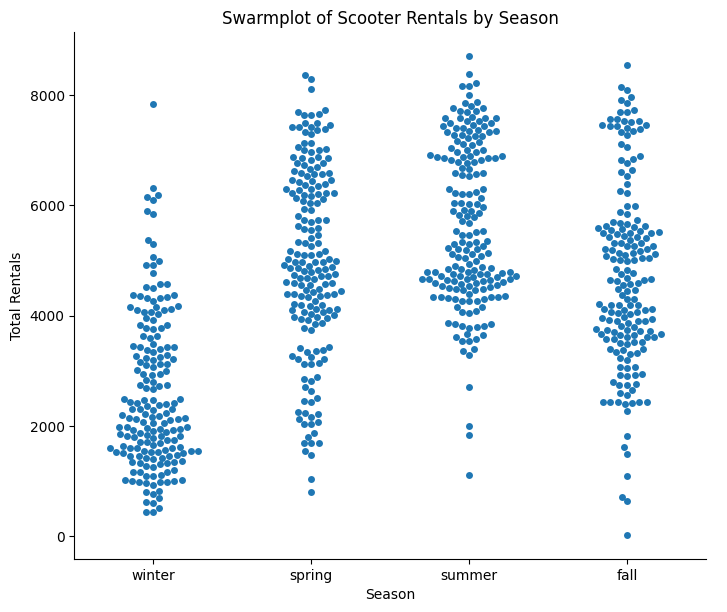

In [43]:
# a swarmplot that explore the total rentals by season
import seaborn as sns
import matplotlib.pyplot as plt

# Swarmplot: rentals_total by season
sns.catplot(
    data=df,
    x="season",
    y="rentals_total",
    kind="swarm",
    height=6,
    aspect=1.2
)

# Add labels and title
plt.xlabel("Season")
plt.ylabel("Total Rentals")
plt.title("Swarmplot of Scooter Rentals by Season")
plt.show()

Generate **a line plot that shows average daily rentals by month and split the lines by year**.  **The "month"**  should on **the x-axis**, the "**rentals_total**" **on the y-axis**, and there should be a line for each value in the "year" column.  Use seaborn's "relplot" function, and make it look like the first chart under the "plotting subsets of data with semantic mappings” section on this page of the seaborn documentation.

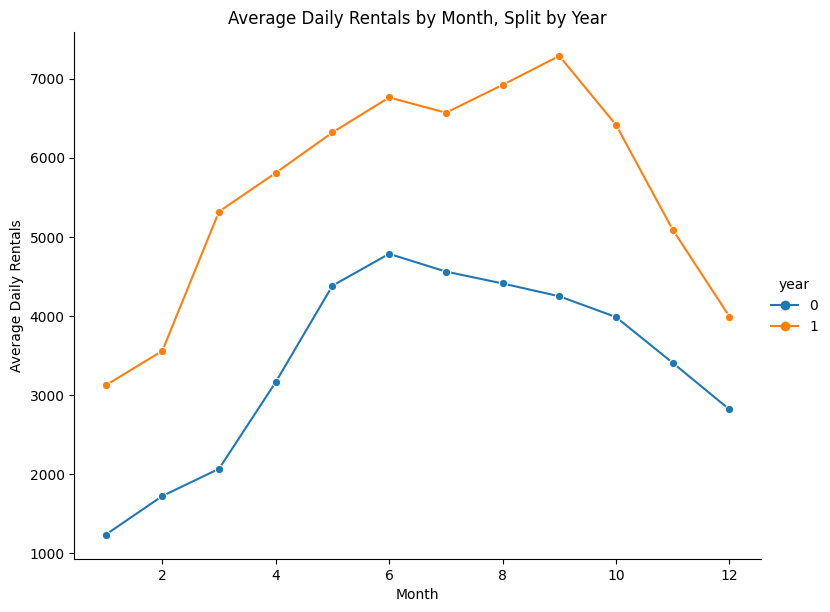

In [45]:

# a line plot that shows average daily rentals by month and split the lines by year

#import seaborn as sns
import matplotlib.pyplot as plt

# First, group by year and month to calculate average rentals
avg_rentals = df.groupby(['year', 'month'])['rentals_total'].mean().reset_index()

# Line plot: average daily rentals by month, split by year
sns.relplot(
    data=avg_rentals,
    x="month",
    y="rentals_total",
    kind="line",
    hue="year",          # separate lines for each year
    marker="o",          # add markers to each point
    height=6,
    aspect=1.3
)

# Add labels and title
plt.xlabel("Month")
plt.ylabel("Average Daily Rentals")
plt.title("Average Daily Rentals by Month, Split by Year")
plt.show()


Generate ***a pairplot to show the relationship between "rentals_total" and the weather indicators ("temp_norm", "temp_felt_norm", "humidity_norm", and "wind_norm")***, which are continuous variables.  Use seaborn's "pairplot" function and set the kind="kde".

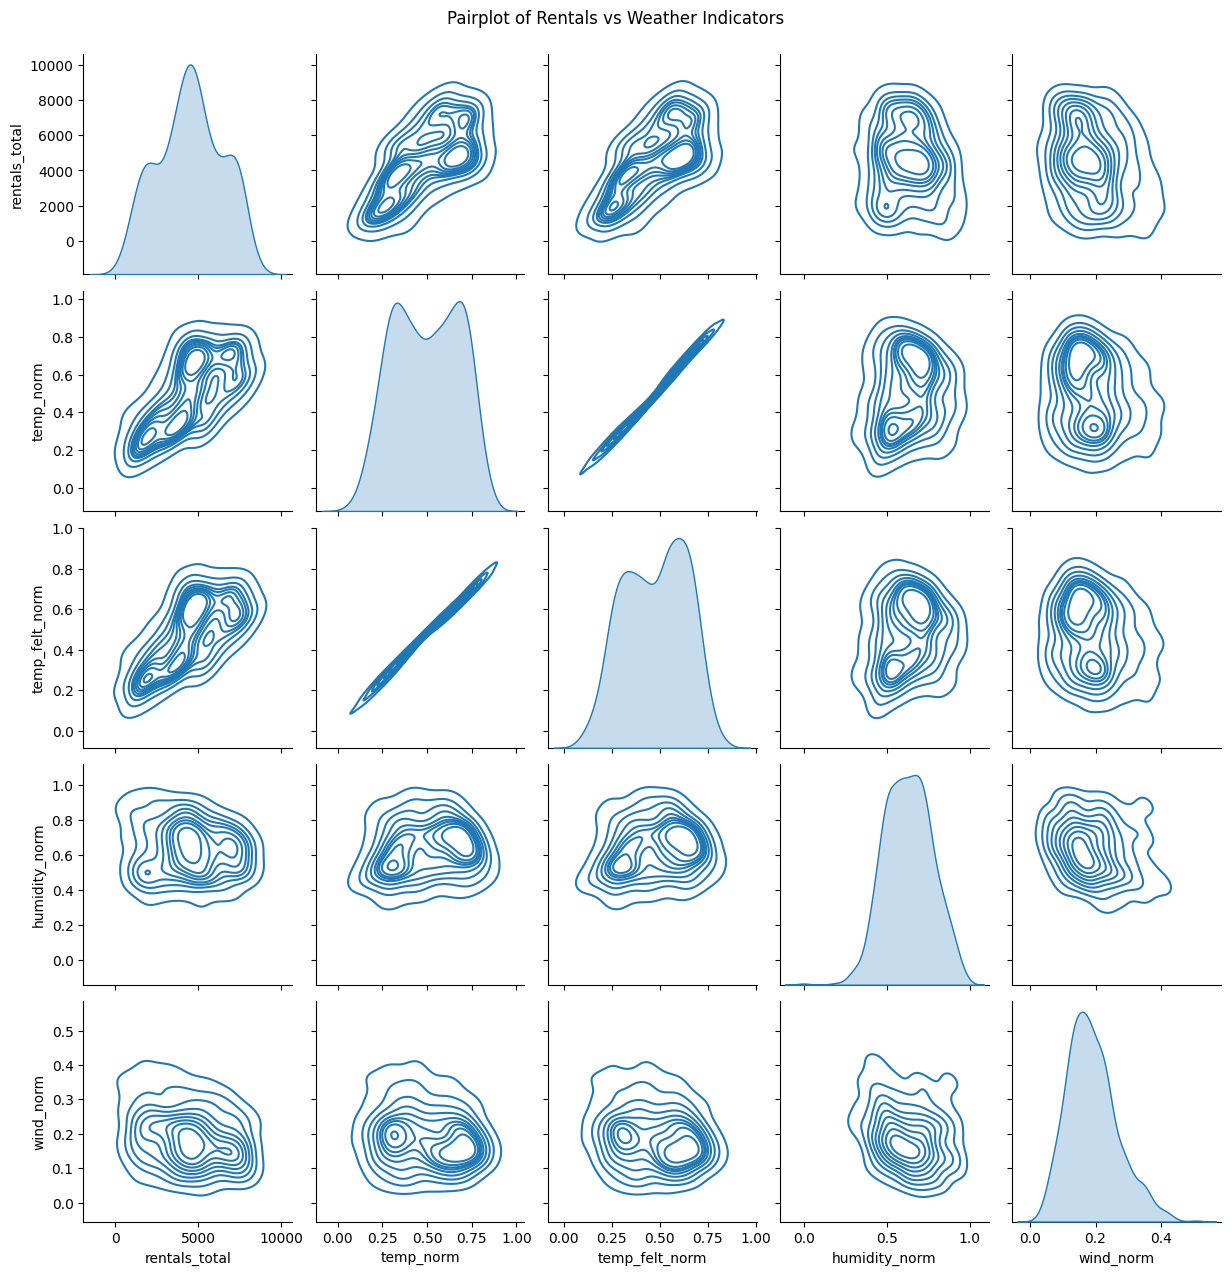

In [46]:
# a pairplot to show the relationship between "rentals_total" and the weather indicators ("temp_norm", "temp_felt_norm", "humidity_norm", and "wind_norm")

import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant columns
weather_data = df[['rentals_total', 'temp_norm', 'temp_felt_norm', 'humidity_norm', 'wind_norm']]

# Generate pairplot with KDE plots
sns.pairplot(
    weather_data,
    kind="kde",       # use kernel density estimate plots
    diag_kind="kde",  # KDE on the diagonal
    height=2.5
)

plt.suptitle("Pairplot of Rentals vs Weather Indicators", y=1.02)
plt.show()


Generate  ***a heatmap to visualize the correlation   between "rentals_total" and the weather indicators*** mentioned in the previous question.  Ensure that the correlations coefficients are shown on the heatmap.  Use seaborn's "heatmap" function and add coefficients by including annot=TRUE.

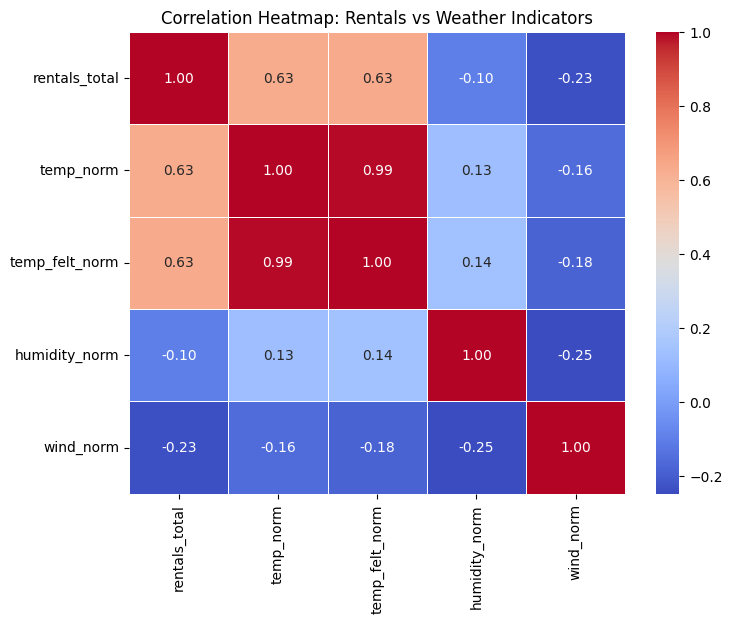

In [47]:
# a heatmap to visualize the correlation between "rentals_total" and the weather indicators mentioned in the previous question
import seaborn as sns
import matplotlib.pyplot as plt

# Select relevant columns
corr_data = df [['rentals_total', 'temp_norm', 'temp_felt_norm', 'humidity_norm', 'wind_norm']]

# Compute correlation matrix
corr_matrix = corr_data.corr()

# Generate heatmap with correlation coefficients
plt.figure(figsize=(8,6))
sns.heatmap(
    corr_matrix,
    annot=True,        # show correlation coefficients
    cmap="coolwarm",   # color palette
    fmt=".2f",         # format coefficients to 2 decimal places
    linewidths=0.5
)

plt.title("Correlation Heatmap: Rentals vs Weather Indicators")
plt.show()


 By looking at the heatmap (or a correlation matrix), what is the the correlation coefficient (r) that quantifies the strength of the relationship between "rentals_total" and "temp_norm"?


In [52]:
r_value = df['rentals_total'].corr(df['temp_norm'])
print(f"Correlation coefficient (r): {r_value:.2f}")

Correlation coefficient (r): 0.63


## Summary:

### Q&A
The correlation coefficient between `rentals_total` and `temp_norm` is 0.63.

### Data Analysis Key Findings
*   The original code incorrectly attempted to access the `rentals_total` column from `df_scooter`, which did not contain the necessary data.
*   The `df` DataFrame was correctly identified as containing both `rentals_total` and `temp_norm` columns.
*   After correcting the code to use the `df` DataFrame, the calculated correlation coefficient between `rentals_total` and `temp_norm` was found to be 0.63.

### Insights or Next Steps
*   The positive correlation coefficient of 0.63 indicates a moderately strong positive relationship between `rentals_total` and `temp_norm`, suggesting that scooter rentals tend to increase as normalized temperature rises.
*   Further analysis could explore the statistical significance of this correlation and investigate other environmental or temporal factors that might influence scooter rental demand.


**I am build a model to predict scooter rentals given temperatures.**

In [54]:
# Separate the dependent variable (use "rentals_total") and the independent variable (use "temp_norm").
# Split the data into training and test sets.  (Put 25% into the test set.)Train ("fit") the linear regression model using the training data.

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# 1. Separate dependent (y) and independent (X) variables
X = df[['temp_norm']]       # independent variable
y = df['rentals_total']     # dependent variable

# 2. Split into training and test sets (25% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# 3. Train (fit) the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Preview coefficients
print("Intercept:", model.intercept_)
print("Coefficient for temp_norm:", model.coef_[0])

Intercept: 1278.8499909898105
Coefficient for temp_norm: 6573.124026560643


In [56]:
# Display the regression intercept
print("Regression Intercept:", model.intercept_)


Regression Intercept: 1278.8499909898105


In [57]:
# Display the regression coefficient for temp_norm
print("Regression Coefficient for temp_norm:", round(model.coef_[0], 2))


Regression Coefficient for temp_norm: 6573.12


In [58]:
# Suppose you want to predict rentals at temp_norm = 0.65
temp_value = 0.65

# Prediction using the trained model
predicted_rentals = model.predict([[temp_value]])

print(f"Predicted rentals at temp_norm={temp_value}: {predicted_rentals[0]:.0f}")


Predicted rentals at temp_norm=0.65: 5551


In [59]:
# Example prediction at temp_norm = 0.30
temp_value = 0.30
predicted_rentals = model.intercept_ + model.coef_[0] * temp_value

print(f"Predicted rentals: {predicted_rentals:.2f}")


Predicted rentals: 3250.79


In [61]:
temp_value = 0.30
predicted_rentals = model.intercept_ + model.coef_[0] * temp_value
print(f"Predicted rentals: {predicted_rentals:.2f}")

Predicted rentals: 3250.79


In [62]:
from sklearn.metrics import r2_score

# Predict rentals on the test set
y_pred = model.predict(X_test)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)
print("R-squared:", round(r2, 2))


R-squared: 0.41
